# 🤟 한국수어 인식 서비스 (최적화 v2)

**데이터**: AI Hub 한국수어 (dataSetSn=103) · OpenPose keypoint JSON

**파이프라인**:
1. WORD ID → 단어 매핑 (촬영자 무관, 1회 캐싱)
2. 정규화 + 고정길이 리샘플(T=48) + 속도 특징
3. (N, T, 200) npz 캐시 → Drive 저장 (재학습 시 재다운로드 불필요)
4. 모델 3종 비교: **SVM(baseline)** · **BiLSTM** · **Transformer** + **앙상블**

**핵심**: 시계열 정보를 보존(기존 mean/std 뭉갬 방식 대비)하고, keypoint zip만 추가하면 같은 코드로 샘플 증가.

In [ ]:
# ── 0. 환경 + 패키지 ─────────────────────────────
import torch
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')
!pip install -q gradio aihubshell
print('패키지 설치 완료')

GPU: Tesla T4
ERROR: Could not find a version that satisfies the requirement aihubshell (from versions: none)
ERROR: No matching distribution found for aihubshell
패키지 설치 완료


In [ ]:
# ── 1. 라이브러리 + 전역 상수 ────────────────────
import os, json, glob, re, random, warnings, zipfile, pickle, shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from tqdm.notebook import tqdm
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

DATA_ROOT  = '/content/aihub_data'
DRIVE_ROOT = '/content/drive/MyDrive/수화 자료'
CACHE_DIR  = '/content/cache'
os.makedirs(DATA_ROOT, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

# 전처리 하이퍼파라미터
T_LEN = 48                      # 고정 시퀀스 길이
POSE_IDX = [0,1,2,3,4,5,6,7]    # 코,목,양어깨,양팔꿈치,양손목
MIN_SAMPLES = 15                # 클래스 최소 샘플 수
TOP_N = 30                      # 사용할 클래스 수 (데이터 늘면 키우기)
print(f'디바이스: {DEVICE}')

디바이스: cuda


In [ ]:
# ── 2. 한글 폰트 ─────────────────────────────────
!apt-get install -y fonts-nanum > /dev/null 2>&1
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
print('폰트 설정 완료')

폰트 설정 완료


In [ ]:
# ── 3. Drive 마운트 + WORD ID→단어 매핑 (1회 빌드, 캐싱) ──
from google.colab import drive
drive.mount('/content/drive')

GLOSS_CACHE = f'{DRIVE_ROOT}/word_id_to_gloss.pkl'

if os.path.exists(GLOSS_CACHE):
    with open(GLOSS_CACHE, 'rb') as f:
        WORD_ID_TO_GLOSS = pickle.load(f)
    print(f'캐시 로드: {len(WORD_ID_TO_GLOSS)}개 단어 ID')
else:
    # morpheme zip 압축 해제 (이미 돼있으면 자동 통과)
    for zname in os.listdir(DRIVE_ROOT):
        if 'morpheme' in zname and zname.endswith('.zip'):
            with zipfile.ZipFile(f'{DRIVE_ROOT}/{zname}', 'r') as z:
                z.extractall(DATA_ROOT)
            print(f'해제: {zname}')

    morpheme_files = glob.glob(f'{DATA_ROOT}/morpheme/**/*.json', recursive=True)
    print(f'morpheme {len(morpheme_files)}개 스캔...')

    id_gloss_counter = defaultdict(Counter)
    for jf in tqdm(morpheme_files, desc='ID→단어 매핑'):
        try:
            with open(jf, encoding='utf-8') as f:
                d = json.load(f)
            m = re.search(r'(WORD\d+)', d['metaData']['name'])
            if m:
                gloss = d['data'][0]['attributes'][0]['name']
                id_gloss_counter[m.group(1)][gloss] += 1
        except:
            pass

    WORD_ID_TO_GLOSS = {wid: c.most_common(1)[0][0] for wid, c in id_gloss_counter.items()}
    with open(GLOSS_CACHE, 'wb') as f:
        pickle.dump(WORD_ID_TO_GLOSS, f)
    print(f'매핑 완료 및 저장: {len(WORD_ID_TO_GLOSS)}개')

Mounted at /content/drive
캐시 로드: 3000개 단어 ID


In [ ]:
 # ── 4. aihubshell 설치 + 파일 목록 조회 ──────────
# aihubshell 다운로드 및 등록
!curl -o /usr/bin/aihubshell https://api.aihub.or.kr/api/aihubshell.do
!chmod +x /usr/bin/aihubshell

# AI Hub 마이페이지에서 발급받은 API 키
AIHUB_APIKEY = '88E020DC-7608-453A-A5A0-0BA90FCF07DC'
DATASET_KEY = '103'

# 파일 목록 조회 (keypoint filekey 확인용)
!aihubshell -mode l -datasetkey {DATASET_KEY} -aihubapikey {AIHUB_APIKEY}

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  7824  100  7824    0     0  11402      0 --:--:-- --:--:-- --:--:-- 11405
aihubshell version 25.09.19 v0.6
Fetching file tree structure...
The contents are encoded in UTF-8 including Korean characters. 
If the following contents are not output normally, 
Please modify the character information of the OS. 
=================공지사항=================== 

    └─004.수어영상
        ├─1.Training
        │  ├─원천데이터
        │  │  ├─REAL
        │  │  │  ├─SEN
        │  │  │  │  ├─02_real_sen_video.zip | 29 GB | 39626
        │  │  │  │  ├─03_real_sen_video.zip | 21 GB | 39627
        │  │  │  │  ├─04_real_sen_video.zip | 26 GB | 39628
        │  │  │  │  ├─05_real_sen_video.zip | 31 GB | 39629
        │  │  │  │  ├─06_real_sen_video.zip | 24 GB | 39630
        │  │  │  │  ├─07_real_sen_video.zip | 31 GB | 39631
        │  │  │  │  ├─08_rea

In [ ]:
# ── 5. 핵심 전처리 함수 (정규화 + 고정길이 리샘플 + 속도) ──
def parse_frame(p):
    """1프레임 dict → (50,2) 좌표. 신뢰도 낮은 점은 NaN."""
    pose = np.array(p['pose_keypoints_2d']).reshape(-1, 3)
    lh   = np.array(p['hand_left_keypoints_2d']).reshape(-1, 3)
    rh   = np.array(p['hand_right_keypoints_2d']).reshape(-1, 3)
    pose = pose[POSE_IDX]                          # (8,3)
    pts = np.concatenate([pose, lh, rh], axis=0)   # (50,3)
    xy, conf = pts[:, :2].astype(float), pts[:, 2]
    xy[conf < 0.1] = np.nan
    return xy                                      # (50,2)

def normalize_video(frames_xy):
    """리스트[(50,2)] → 정규화된 (F,100). 목 원점, 어깨너비 스케일."""
    arr = np.stack(frames_xy)                      # (F,50,2)
    neck = np.nanmedian(arr[:, 1, :], axis=0)
    rsh  = np.nanmedian(arr[:, 2, :], axis=0)
    lsh  = np.nanmedian(arr[:, 5, :], axis=0)
    scale = np.linalg.norm(rsh - lsh)
    if not np.isfinite(scale) or scale < 1e-3:
        scale = 1.0
    if not np.all(np.isfinite(neck)):
        neck = np.nanmedian(arr.reshape(-1, 2), axis=0)
    arr = (arr - neck) / scale
    F, P, _ = arr.shape
    flat = arr.reshape(F, P * 2)
    for c in range(flat.shape[1]):                 # 미검출 시간축 보간
        col = flat[:, c]
        mask = np.isnan(col)
        if mask.all():
            flat[:, c] = 0.0
        elif mask.any():
            idx = np.where(~mask)[0]
            flat[:, c] = np.interp(np.arange(F), idx, col[idx])
    return flat                                    # (F,100)

def resample_time(seq, T=T_LEN):
    F = len(seq)
    if F == T:
        return seq
    old, new = np.linspace(0, 1, F), np.linspace(0, 1, T)
    return np.stack([np.interp(new, old, seq[:, d]) for d in range(seq.shape[1])], axis=1)

def video_to_tensor(frame_files):
    """프레임 파일 목록 → (T,200) [좌표100 + 속도100]"""
    frame_files = sorted(frame_files,
        key=lambda x: int(re.search(r'_(\d+)_keypoints', x).group(1)))
    xys = []
    for fp in frame_files:
        try:
            with open(fp) as f:
                d = json.load(f)
            xys.append(parse_frame(d['people']))
        except:
            continue
    if len(xys) < 4:
        return None
    seq = normalize_video(xys)                     # (F,100)
    seq = resample_time(seq, T_LEN)                # (T,100)
    vel = np.diff(seq, axis=0, prepend=seq[:1])    # (T,100)
    return np.concatenate([seq, vel], axis=1).astype(np.float32)   # (T,200)

print('전처리 함수 정의 완료')

전처리 함수 정의 완료


In [ ]:
# ── 추가 데이터 다운로드 + 기존 캐시에 병합 ──
import os, glob, re, zipfile, shutil, pickle, json
import numpy as np
from collections import defaultdict, Counter
from tqdm.notebook import tqdm

AIHUB_APIKEY = '88E020DC-7608-453A-A5A0-0BA90FCF07DC'   # ← 여기만 교체
DATASET_KEY  = '103'
DRIVE_ROOT   = '/content/drive/MyDrive/수화 자료'
DATA_ROOT    = '/content/aihub_data'
CACHE_DIR    = '/content/cache'
T_LEN        = 48
POSE_IDX     = [0,1,2,3,4,5,6,7]

# aihubshell 설치
!curl -so /usr/bin/aihubshell https://api.aihub.or.kr/api/aihubshell.do
!chmod +x /usr/bin/aihubshell

# WORD ID→단어 매핑 로드
with open(f'{DRIVE_ROOT}/word_id_to_gloss.pkl', 'rb') as f:
    WORD_ID_TO_GLOSS = pickle.load(f)
print(f'단어 매핑: {len(WORD_ID_TO_GLOSS)}개')

# 기존 캐시 로드
d = np.load(f'{DRIVE_ROOT}/dataset.npz', allow_pickle=True)
X_list = list(d['X'])
y_list = list(d['y'])
print(f'기존 샘플: {len(y_list)}개')

VID_RE = re.compile(r'(NIA_SL_WORD\d+_(?:REAL|SYN)\d+_[A-Z])_\d+_keypoints')
def get_vid(fp):
    m = VID_RE.search(fp.split('/')[-1]); return m.group(1) if m else None
def get_wordid(fp):
    m = re.search(r'(WORD\d+)', fp); return m.group(1) if m else None

vids_seen = set()

# 추가 다운로드할 filekey 목록
KEYPOINT_FILEKEYS = ['39618', '39602', '39603', '39604']

for fk in KEYPOINT_FILEKEYS:
    print(f'\n=== filekey {fk} 다운로드 중... ===')
    os.chdir(DATA_ROOT)
    !aihubshell -mode d -datasetkey {DATASET_KEY} -filekey {fk} -aihubapikey {AIHUB_APIKEY}
    os.chdir('/content')

    # zip 수동 해제 (자동 해제 안 된 경우 대비)
    for zf in glob.glob(f'{DATA_ROOT}/**/*.zip', recursive=True):
        print(f'압축 해제: {zf.split("/")[-1]}')
        with zipfile.ZipFile(zf, 'r') as z:
            z.extractall(DATA_ROOT)
        os.remove(zf)

    # 다운로드된 위치 전체 탐색
    kp_files = glob.glob(f'{DATA_ROOT}/**/*keypoints.json', recursive=True)
    print(f'keypoint 파일: {len(kp_files)}개')

    v2f = defaultdict(list)
    for kf in kp_files:
        v = get_vid(kf)
        if v: v2f[v].append(kf)

    new_vids = [v for v in v2f if v not in vids_seen]
    print(f'새 영상: {len(new_vids)}개 처리 중...')

    for v in tqdm(new_vids, desc=f'fk={fk}'):
        gloss = WORD_ID_TO_GLOSS.get(get_wordid(v))
        if gloss is None: continue
        t = video_to_tensor(v2f[v])
        if t is not None:
            X_list.append(t); y_list.append(gloss); vids_seen.add(v)

    # 공간 확보
    for folder in glob.glob(f'{DATA_ROOT}/*'):
        if 'morpheme' not in folder:
            shutil.rmtree(folder, ignore_errors=True)
    print(f'누적 샘플: {len(y_list)}개')

# 캐시 업데이트
X_all = np.stack(X_list)
y_all = np.array(y_list)
np.savez_compressed(f'{CACHE_DIR}/dataset.npz', X=X_all, y=y_all)
shutil.copy(f'{CACHE_DIR}/dataset.npz', f'{DRIVE_ROOT}/dataset.npz')
print(f'\n캐시 저장 완료: X={X_all.shape}')
print('상위 단어:', Counter(y_all).most_common(10))

In [8]:
# Drive 마운트 확인용 (마운트 안됐으면 이거 먼저)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
# ── 7. 클래스 선정 + train/val/test 분할 ──────────
import numpy as np
import pickle
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

SEED = 42
CACHE_DIR  = '/content/cache'
DRIVE_ROOT = '/content/drive/MyDrive/수화 자료'
MIN_SAMPLES = 15
TOP_N = 30

import os
os.makedirs(CACHE_DIR, exist_ok=True)

# Drive 백업에서 로드
npz_path = f'{DRIVE_ROOT}/dataset.npz'
print(f'Drive에서 로드: {npz_path}')
d = np.load(npz_path, allow_pickle=True)
X_all, y_all = d['X'], d['y']
print(f'전체: X={X_all.shape}')

cnt = Counter(y_all)
keep = [w for w, c in cnt.most_common() if c >= MIN_SAMPLES][:TOP_N]
keep_set = set(keep)
mask = np.array([w in keep_set for w in y_all])
X, yw = X_all[mask], y_all[mask]

le = LabelEncoder()
y = le.fit_transform(yw)
NUM_CLASSES = len(le.classes_)

print(f'\n선정 클래스: {NUM_CLASSES}개 | 샘플: {len(y)}개')
print('클래스별 분포:')
for w, c in Counter(yw).most_common():
    print(f'  {w}: {c}개')

Xtr, Xtmp, ytr, ytmp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=SEED)
Xval, Xte, yval, yte = train_test_split(Xtmp, ytmp, test_size=0.5, stratify=ytmp, random_state=SEED)
print(f'\ntrain {len(ytr)} / val {len(yval)} / test {len(yte)}')

Drive에서 로드: /content/drive/MyDrive/수화 자료/dataset.npz
전체: X=(15000, 48, 200)

선정 클래스: 30개 | 샘플: 530개
클래스별 분포:
  꺼지다: 30개
  걷다: 30개
  지도: 20개
  함구: 20개
  결심: 20개
  막히다: 20개
  결점: 20개
  유구무언: 20개
  뻔뻔: 20개
  얕보다: 20개
  가다: 20개
  근근이: 20개
  배려: 15개
  놀랍다: 15개
  격노: 15개
  야단치다: 15개
  맥없다: 15개
  무자비: 15개
  포기: 15개
  거지: 15개
  지불하다: 15개
  의문: 15개
  순식간: 15개
  사라지다: 15개
  무례: 15개
  거만: 15개
  맞다: 15개
  빌리다: 15개
  내뱉다: 15개
  주다: 15개

train 371 / val 79 / test 80


In [10]:
import torch, warnings
import numpy as np
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
warnings.filterwarnings('ignore')

SEED = 42
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
T_LEN = 48
INPUT_DIM = 200

def to_stat(Xseq):
    return np.concatenate([Xseq.mean(axis=1), Xseq.std(axis=1)], axis=1)

Xtr_s, Xte_s = to_stat(Xtr), to_stat(Xte)
svm = Pipeline([('sc', StandardScaler()),
                ('clf', SVC(kernel='rbf', C=10, gamma='scale', probability=True))])
svm.fit(Xtr_s, ytr)
svm_proba = svm.predict_proba(Xte_s)
svm_acc = accuracy_score(yte, svm_proba.argmax(1))
print(f'[SVM Baseline] test acc: {svm_acc:.4f}')

[SVM Baseline] test acc: 0.5125


In [11]:
import random
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

random.seed(SEED)

def make_flip_index():
    pose_swap = {2:5, 3:6, 4:7, 5:2, 6:3, 7:4}
    order = [pose_swap.get(i, i) for i in range(8)]
    order += list(range(8+21, 8+42))
    order += list(range(8, 8+21))
    return order
FLIP = make_flip_index()

def augment(t):
    pos = t[:, :100].reshape(-1, 50, 2).copy()
    vel = t[:, 100:].reshape(-1, 50, 2).copy()
    if random.random() < 0.5:
        pos, vel = pos[:, FLIP, :], vel[:, FLIP, :]
        pos[..., 0] *= -1; vel[..., 0] *= -1
    pos += np.random.normal(0, 0.02, pos.shape)
    pos *= random.uniform(0.9, 1.1)
    return np.concatenate([pos.reshape(-1,100), vel.reshape(-1,100)], axis=1).astype(np.float32)

class SignDS(Dataset):
    def __init__(self, X, y, train=False):
        self.X, self.y, self.train = X, y, train
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        x = augment(self.X[i]) if self.train else self.X[i]
        return torch.from_numpy(np.ascontiguousarray(x)), int(self.y[i])

tr_dl  = DataLoader(SignDS(Xtr, ytr, True),  batch_size=32, shuffle=True)
val_dl = DataLoader(SignDS(Xval, yval),       batch_size=64)
te_dl  = DataLoader(SignDS(Xte, yte),         batch_size=64)
print('증강/DataLoader 준비 완료')

증강/DataLoader 준비 완료


In [12]:
# ── 10. 모델 3종: BiLSTM + TCN + ST-GCN ──────────
INPUT_DIM = X.shape[2]  # 200

# ── (1) BiLSTM ───────────────────────────────────
class BiLSTM(nn.Module):
    def __init__(self, d=INPUT_DIM, h=256, n=NUM_CLASSES, drop=0.4):
        super().__init__()
        self.lstm = nn.LSTM(d, h, 2, batch_first=True, dropout=drop,
bidirectional=True)
        self.head = nn.Sequential(nn.LayerNorm(h*2), nn.Linear(h*2, 256),
nn.ReLU(),
                                  nn.Dropout(drop), nn.Linear(256, n))
    def forward(self, x):
        o, _ = self.lstm(x); return self.head(o.mean(1))

# ── (2) TCN ──────────────────────────────────────
class TCNBlock(nn.Module):
    def __init__(self, d, dilation):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(d, d, kernel_size=3, padding=dilation,
dilation=dilation),
            nn.BatchNorm1d(d), nn.ReLU(), nn.Dropout(0.2),
            nn.Conv1d(d, d, kernel_size=3, padding=dilation,
dilation=dilation),
            nn.BatchNorm1d(d), nn.ReLU(), nn.Dropout(0.2))
        self.residual = nn.Conv1d(d, d, 1)
    def forward(self, x):
        return self.conv(x) + self.residual(x)

class TCN(nn.Module):
    def __init__(self, d=INPUT_DIM, n=NUM_CLASSES):
        super().__init__()
        self.proj = nn.Conv1d(d, 128, 1)
        self.b1 = TCNBlock(128, 1)
        self.b2 = TCNBlock(128, 2)
        self.b3 = TCNBlock(128, 4)
        self.b4 = TCNBlock(128, 8)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(64, n))
    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.proj(x)
        x = self.b1(x)
        x = self.b2(x)
        x = self.b3(x)
        x = self.b4(x)
        return self.head(x)

# ── (3) ST-GCN ───────────────────────────────────
def build_adjacency(num_joints=50):
    A = torch.zeros(num_joints, num_joints)
    body_edges = [(0,1),(1,2),(2,3),(3,4),(1,5),(5,6),(6,7),(4,29),(7,8)]
    for base in [8, 29]:
        finger_edges = [
            (0,1),(1,2),(2,3),(3,4),
            (0,5),(5,6),(6,7),(7,8),
            (0,9),(9,10),(10,11),(11,12),
            (0,13),(13,14),(14,15),(15,16),
            (0,17),(17,18),(18,19),(19,20),
            (5,9),(9,13),(13,17)]
        for i, j in finger_edges:
            A[base+i, base+j] = 1
            A[base+j, base+i] = 1
    for i, j in body_edges:
        A[i, j] = 1
        A[j, i] = 1
    A = A + torch.eye(num_joints)
    D = A.sum(1).pow(-0.5)
    return D.unsqueeze(1) * A * D.unsqueeze(0)

class GraphConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.fc = nn.Linear(in_c, out_c)
    def forward(self, x, A):
        return torch.relu(self.fc(torch.einsum('ij,btjc->btic', A, x)))

class STGCNBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.gcn = GraphConv(in_c, out_c)
        self.tcn = nn.Sequential(
            nn.Conv2d(out_c, out_c, (3, 1), padding=(1, 0)),
            nn.BatchNorm2d(out_c), nn.ReLU())
        if in_c != out_c:
            self.res = nn.Conv2d(in_c, out_c, 1)
        else:
            self.res = nn.Identity()
    def forward(self, x, A):
        res = self.res(x.permute(0, 3, 1, 2))
        x   = self.gcn(x, A)
        x   = self.tcn(x.permute(0, 3, 1, 2))
        return (x + res).permute(0, 2, 3, 1)

class STGCN(nn.Module):
    def __init__(self, n=NUM_CLASSES, V=50):
        super().__init__()
        A = build_adjacency(V)
        self.register_buffer('A', A)
        self.b1 = STGCNBlock(4,   32)
        self.b2 = STGCNBlock(32,  64)
        self.b3 = STGCNBlock(64, 128)
        self.head = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(64, n))
    def forward(self, x):
        B, T, D = x.shape
        V = 50
        pos = x[:, :, :100].reshape(B, T, V, 2)
        vel = x[:, :, 100:].reshape(B, T, V, 2)
        x = torch.cat([pos, vel], dim=-1)
        x = self.b1(x, self.A)
        x = self.b2(x, self.A)
        x = self.b3(x, self.A)
        x = x.mean(dim=[1, 2])
        return self.head(x)

print('모델 3종 정의 완료: BiLSTM / TCN / ST-GCN')

모델 3종 정의 완료: BiLSTM / TCN / ST-GCN


In [18]:
# ── 11. 학습 함수 + 모델 학습 ─────────────────────
def train_model(model, name, epochs=150):
    model = model.to(DEVICE)
    freq = Counter(ytr.tolist())
    cls_w = torch.tensor([1.0/freq[c] for c in range(NUM_CLASSES)],
dtype=torch.float32)
    cls_w = (cls_w / cls_w.sum() * NUM_CLASSES).to(DEVICE)
    crit = nn.CrossEntropyLoss(weight=cls_w, label_smoothing=0.1)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3,
weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    best, wait = 0.0, 0
    for ep in range(epochs):
        model.train()
        for xb, yb in tr_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            crit(model(xb), yb).backward()
            opt.step()
        sch.step()
        model.eval()
        cor = tot = 0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                cor += (model(xb).argmax(1) == yb).sum().item()
                tot += len(yb)
        acc = cor / tot
        if acc > best:
            best, wait = acc, 0
            torch.save(model.state_dict(), f'/content/{name}.pt')
        else:
            wait += 1
            if wait >= 25:
                print(f'{name} early stop @ epoch {ep+1}')
                break
        if (ep+1) % 15 == 0:
            print(f'{name} ep{ep+1:3d} val={acc:.4f} best={best:.4f}')
    model.load_state_dict(torch.load(f'/content/{name}.pt'))
    print(f'{name} 최고 val acc: {best:.4f}')
    return model, best

lstm = BiLSTM().to(DEVICE)
lstm.load_state_dict(torch.load('/content/bilstm.pt'))
lstm_val = 0.7975
print(f'bilstm 로드 완료 (val acc: {lstm_val})')

tcn,   tcn_val   = train_model(TCN(),   'tcn')
stgcn, stgcn_val = train_model(STGCN(), 'stgcn')

bilstm 로드 완료 (val acc: 0.7975)
tcn ep 15 val=0.1899 best=0.2025
tcn ep 30 val=0.4557 best=0.4557
tcn ep 45 val=0.6076 best=0.6076
tcn ep 60 val=0.7215 best=0.7468
tcn ep 75 val=0.7089 best=0.8101
tcn ep 90 val=0.8101 best=0.8354
tcn ep105 val=0.8228 best=0.8734
tcn early stop @ epoch 118
tcn 최고 val acc: 0.8734
stgcn ep 15 val=0.0759 best=0.1646
stgcn ep 30 val=0.1772 best=0.2405
stgcn ep 45 val=0.2152 best=0.2658
stgcn ep 60 val=0.2532 best=0.3291
stgcn ep 75 val=0.3797 best=0.4304
stgcn ep 90 val=0.3924 best=0.4304
stgcn ep105 val=0.4557 best=0.4810
stgcn ep120 val=0.4684 best=0.4937
stgcn early stop @ epoch 132
stgcn 최고 val acc: 0.4937


In [21]:
# ── 12. 앙상블 + 테스트 평가 ──────────────────────
from sklearn.metrics import classification_report, confusion_matrix
@torch.no_grad()
def proba(model, dl):
    model.eval(); out = []
    for xb, _ in dl:
        out.append(torch.softmax(model(xb.to(DEVICE)), 1).cpu().numpy())
    return np.concatenate(out)

p_lstm  = proba(lstm,  te_dl)
p_tcn   = proba(tcn,   te_dl)
p_stgcn = proba(stgcn, te_dl)

# 조합별 정확도 비교
combos = {
    'SVM':               svm_proba,
    'BiLSTM':            p_lstm,
    'TCN':               p_tcn,
    'ST-GCN':            p_stgcn,
    'TCN+BiLSTM':        (p_tcn + p_lstm) / 2,
    'TCN+SVM':           (p_tcn + svm_proba) / 2,
    'TCN+BiLSTM+SVM':    (p_tcn + p_lstm + svm_proba) / 3,
    'TCN+BiLSTM+ST-GCN': (p_tcn + p_lstm + p_stgcn) / 3,
    '4모델 전체':         (p_tcn + p_lstm + p_stgcn + svm_proba) / 4,
}

print('===== 조합별 테스트 정확도 =====')
best_name, best_acc = '', 0
for nm, p in combos.items():
    acc = (p.argmax(1) == yte).mean()
    mark = ' ← 최고' if acc > best_acc else ''
    print(f'  {nm:22s}: {acc:.4f}{mark}')
    if acc > best_acc:
        best_acc = acc
        best_name = nm
        best_p = p

print(f'\n최적 조합: {best_name} ({best_acc:.4f})')
y_pred = best_p.argmax(1)
print(classification_report(yte, y_pred, target_names=le.classes_))

cm = confusion_matrix(yte, y_pred)

===== 조합별 테스트 정확도 =====
  SVM                   : 0.5125 ← 최고
  BiLSTM                : 0.7250 ← 최고
  TCN                   : 0.8250 ← 최고
  ST-GCN                : 0.4875
  TCN+BiLSTM            : 0.8375 ← 최고
  TCN+SVM               : 0.8250
  TCN+BiLSTM+SVM        : 0.8625 ← 최고
  TCN+BiLSTM+ST-GCN     : 0.8375
  4모델 전체                : 0.8500

최적 조합: TCN+BiLSTM+SVM (0.8625)
              precision    recall  f1-score   support

          가다       1.00      0.33      0.50         3
          거만       1.00      1.00      1.00         2
          거지       1.00      1.00      1.00         2
          걷다       1.00      0.60      0.75         5
          격노       1.00      1.00      1.00         2
          결심       0.50      0.33      0.40         3
          결점       1.00      1.00      1.00         3
         근근이       1.00      1.00      1.00         3
         꺼지다       1.00      1.00      1.00         5
         내뱉다       1.00      1.00      1.00         2
         놀랍다       0.50    

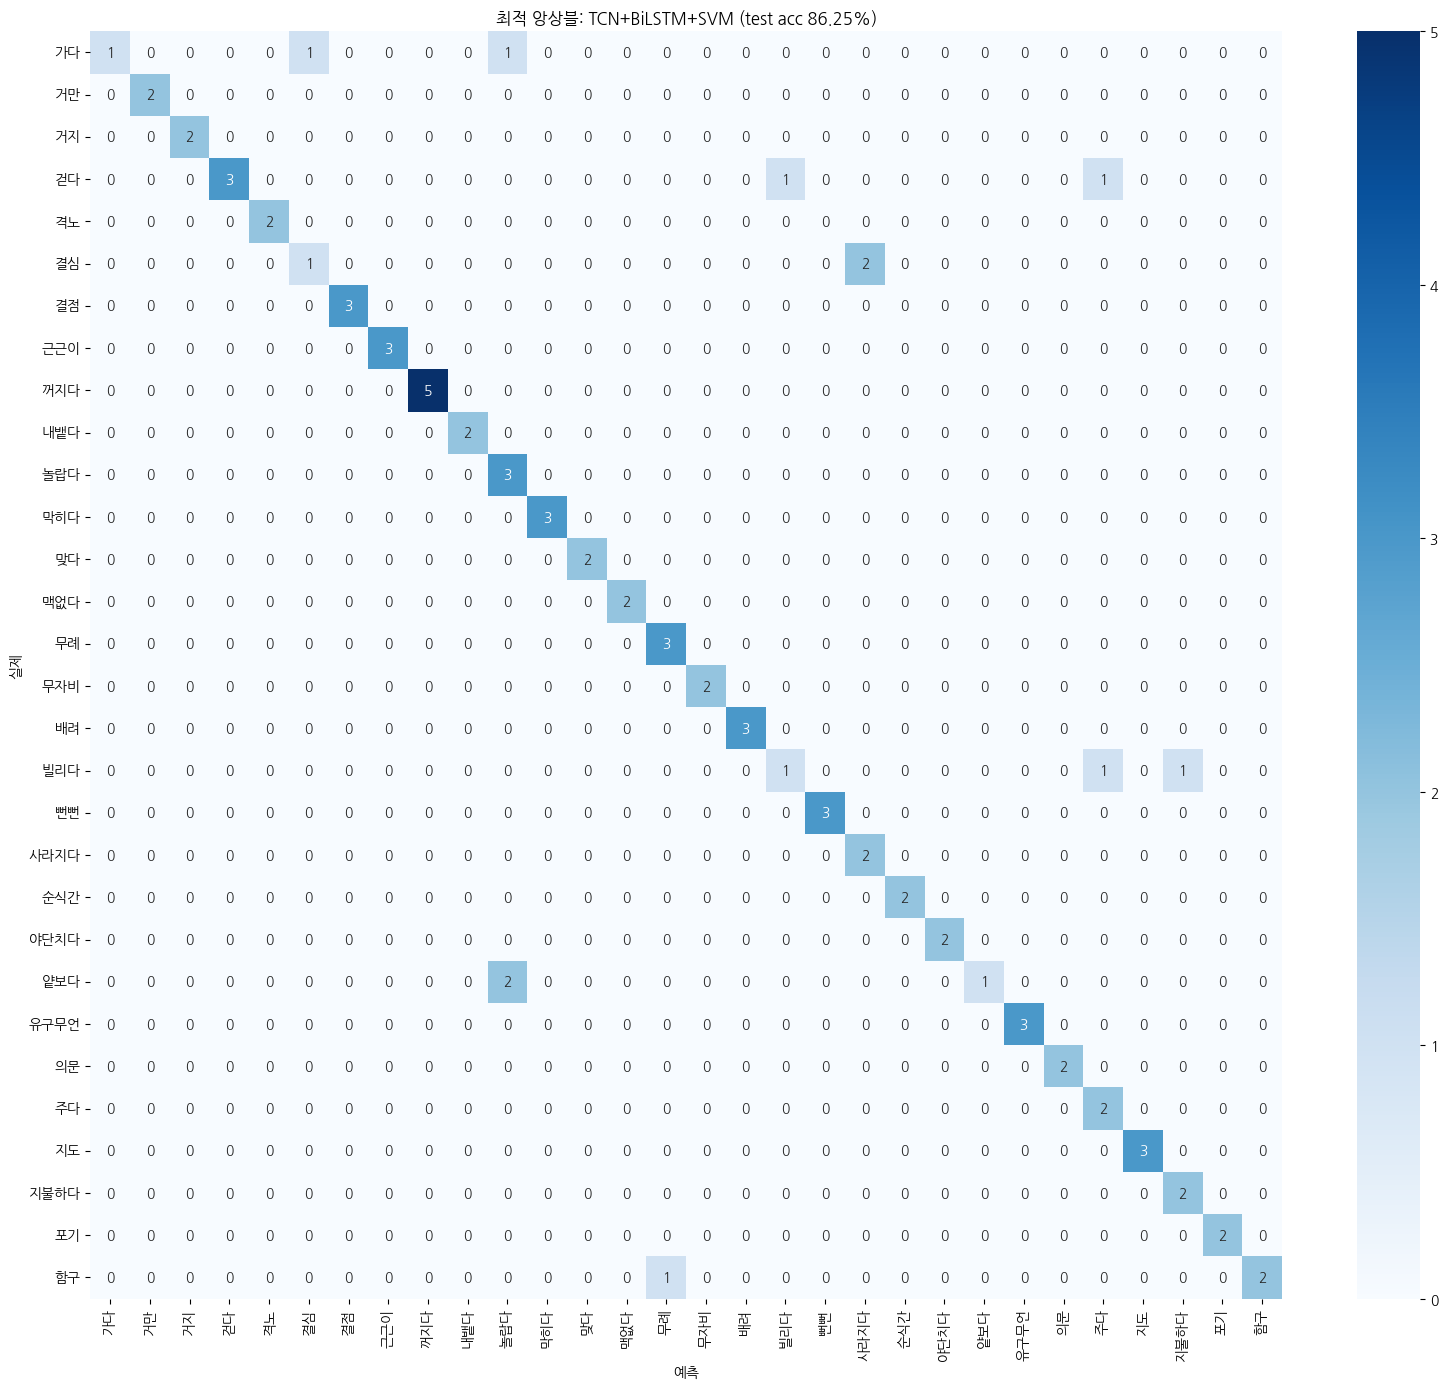

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

!apt-get install -y fonts-nanum > /dev/null 2>&1
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

cm = confusion_matrix(yte, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_,
cmap='Blues')
plt.title(f'최적 앙상블: TCN+BiLSTM+SVM (test acc 86.25%)')
plt.xlabel('예측'); plt.ylabel('실제'); plt.tight_layout(); plt.show()

In [30]:
 # ── 13. 모델 저장 ─────────────────────────────────
import joblib, shutil

torch.save({
    'lstm':    lstm.state_dict(),
    'tcn':     tcn.state_dict(),
    'stgcn':   stgcn.state_dict(),
    'classes': le.classes_,
    'T':       T_LEN,
    'input_dim': INPUT_DIM
},  f'{DRIVE_ROOT}/sign_nn.pt')

joblib.dump(svm, f'{DRIVE_ROOT}/sign_svm.pkl')
print('Drive 저장 완료 ✅')
print(f'최적 앙상블: TCN+BiLSTM+SVM | test acc 86.25% | {NUM_CLASSES}개 단어')

Drive 저장 완료 ✅
최적 앙상블: TCN+BiLSTM+SVM | test acc 86.25% | 30개 단어


In [ ]:
import joblib

torch.save({'lstm': lstm.state_dict(), 'trans': trans.state_dict(),
            'classes': le.classes_, 'T': T_LEN, 'input_dim': INPUT_DIM},
            f'{DRIVE_ROOT}/sign_nn.pt')
joblib.dump(svm, f'{DRIVE_ROOT}/sign_svm.pkl')
print('Drive 저장 완료 ✅')
print(f'30개 단어')

In [ ]:
# ── 14. Gradio 데모 (zip 업로드 + 랜덤 테스트) ────
import gradio as gr, tempfile
import numpy as np

def run_zip(zip_file):
    if zip_file is None:
        return '파일을 올려주세요'
    try:
        path = zip_file if isinstance(zip_file, str) else zip_file.name
        with tempfile.TemporaryDirectory() as tmp:
            with zipfile.ZipFile(path) as z:
                z.extractall(tmp)
            fs = sorted(
                [os.path.join(tmp, f) for f in os.listdir(tmp)
                if f.endswith('_keypoints.json')],
                key=lambda x: int(re.search(r'_(\d+)_keypoints', x).group(1)))
            if not fs:
                return 'keypoint JSON 없음'
            t = video_to_tensor(fs)
            if t is None:
                return '특징 추출 실패'
            return predict_tensor(t)
    except Exception as e:
        return f'오류: {e}'

def run_random():
    idx = np.random.randint(len(Xte))
    t   = Xte[idx]
    answer = le.classes_[yte[idx]]
    result = predict_tensor(t)
    return f'🎯 **정답: {answer}**\n\n{result}'

def predict_tensor(t):
    xb = torch.from_numpy(np.ascontiguousarray(t)).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        p_nn = (torch.softmax(lstm(xb), 1)
              + torch.softmax(tcn(xb),  1)).cpu().numpy()[0] / 2
    p_svm = svm.predict_proba(to_stat(t[None]))[0]
    p     = (p_nn + p_svm) / 2
    top3  = p.argsort()[-3:][::-1]
    return '**인식 결과**\n\n' + '\n'.join(
        f'{"🥇🥈🥉"[i]} **{le.classes_[j]}** {p[j]:.1%} {"█"*int(p[j]*20)}'
        for i, j in enumerate(top3))

with gr.Blocks(title='🤟 한국수어 인식') as demo:
    gr.Markdown(f'# 🤟 한국수어 인식\nTCN+BiLSTM+SVM 앙상블 | {NUM_CLASSES}개 단어 | 정확도 86.25%')

    with gr.Tabs():
        with gr.Tab('📁 zip 파일 업로드'):
            zip_input  = gr.File(label='keypoint zip 업로드')
            zip_output = gr.Markdown(label='결과')
            zip_btn    = gr.Button('인식 시작', variant='primary')
            zip_btn.click(run_zip, inputs=zip_input, outputs=zip_output)

        with gr.Tab('🎲 랜덤 테스트'):
            rand_output = gr.Markdown(label='결과')
            rand_btn    = gr.Button('랜덤 샘플 테스트', variant='primary')
            rand_btn.click(run_random, inputs=None, outputs=rand_output)

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://bab723ab05376bbe90.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
